In [7]:
from smode_import import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature


ds = xr.open_dataset('../dopplerscatt_gridded.nc')
ds = ds.sel(time=slice('2023-04-19','2023-04-23'), lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))

SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))

IDs=['4696942', '4697436', '4697439', '4697491', '4697629', ]#'4697532',]# , '4697637', '4704406'] # favorites
#IDs=['4696942', '4697436', '4697439', '4697491', '4697629', '4697532', '4697637', '4704406'] # favorites


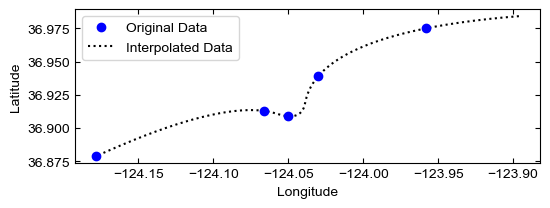

In [8]:
# interpolate eddy core position 
ds = xr.open_dataset('../dopplerscatt_gridded.nc')
ds = ds.sel(time=slice('2023-04-19','2023-04-23'), lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))

lats_slice = [slice(36.9,37), slice(36.9,37), slice(36.85,36.95), slice(36.85,36.95), slice(36.85,36.9)]
lons_slice = [slice(-124,-123.9), slice(-124.1,-124), slice(-124.1,-124,), slice(-124.1,-124.0), slice(-124.2,-124.1)]

max_vor_lats = []
max_vor_lons = []
max_vor_times= []

for i in range(ds.sizes['time']):
    dsi = ds.vorticity.isel(time=i).sel(lat=lats_slice[i],lon=lons_slice[i])
    max_vor = dsi.where(dsi==dsi.max(), drop=True).squeeze()
    max_vor_lats.append(max_vor.lat)
    max_vor_lons.append(max_vor.lon)
    max_vor_times.append(dsi.time.values)

    #plt.figure()
    #ds.vorticity.isel(time=i).plot()
    #plt.plot(max_vor.lon, max_vor.lat, 'ok')

# Convert lists to arrays
max_vor_lats = np.array(max_vor_lats)
max_vor_lons = np.array(max_vor_lons)
max_vor_times = np.array(max_vor_times)

# Create DataArrays
lat_da = xr.DataArray(max_vor_lats, coords=[max_vor_times], dims=['time'], name='lat')
lon_da = xr.DataArray(max_vor_lons, coords=[max_vor_times], dims=['time'], name='lon')

# Combine into a Dataset
ds_max_vorticity = xr.Dataset({'lat': lat_da, 'lon': lon_da})

# Interpolate to hourly timestamps
start_time = pd.Timestamp(str(ds_max_vorticity.time.min().values)) - pd.Timedelta(days=0.5)
end_time = pd.Timestamp(str(ds_max_vorticity.time.max().values))

hourly_times = pd.date_range(start=start_time, end=end_time, freq='0.3h')
hourly_times

ds_max_vorticity['time'] = pd.to_datetime(ds_max_vorticity['time'].values)

# Interpolate to hourly timestamps
ds_interpolated = ds_max_vorticity.interp(time=hourly_times, method='quadratic', kwargs={"fill_value": "extrapolate"})

# Plotting the interpolated positions
plt.figure(figsize=(6,2))
plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'bo', label='Original Data',zorder=101)
plt.plot(ds_interpolated['lon'], ds_interpolated['lat'], 'k:', label='Interpolated Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/eddy-core-location-interpolation.png',dpi=800)
plt.show()


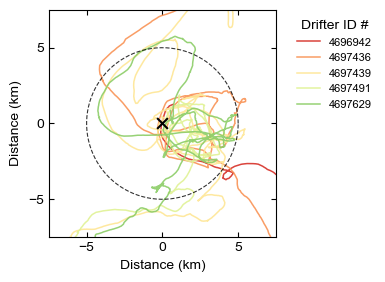

In [9]:
# --- Match Aesthetics from your Vorticity/Divergence Panel ---
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(figsize=(4,4.5))

# 1. Center Core Marker ('x' matching vorticity center style)
ax.scatter(0, 0, marker='x', color='k', s=60, zorder=100)

# 2. 5 km Radius Contour Line (Dashed black line)
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(
    5.0 * np.cos(theta),
    5.0 * np.sin(theta),
    'k--',
    linewidth=0.8,
    alpha=0.8,
    zorder=90,
)

# 3. Get seismic colormap samples across drifters
cmap = plt.get_cmap('RdYlGn')
# Generate evenly spaced color values across the cmap range (avoiding extreme white in center if needed)
colors = [cmap(val) for val in np.linspace(0.1, 0.9, len(IDs)+1)]

# 4. Loop over drifters & plot each in a single distinct color from seismic
for idx, ID in enumerate(IDs):
    drifter = xr.open_dataset(
        SMODE_DATA_folder + f'drifters/2023/SMODE_IOP2_surface_drifter_0-{ID}.nc'
    )
    drifter = drifter.isel(time=drifter.position_QCflag == 1)

    # Interpolate eddy core position to exact drifter timestamps
    core_lon_interp = np.interp(
        drifter.time.astype(float),
        ds_interpolated.time.astype(float),
        ds_interpolated['lon'],
    )
    core_lat_interp = np.interp(
        drifter.time.astype(float),
        ds_interpolated.time.astype(float),
        ds_interpolated['lat'],
    )

    # Relative coordinates [km]
    rel_lon_km = (
        (drifter.longitude - core_lon_interp) * 111.0 * np.cos(np.deg2rad(36.9))
    )
    rel_lat_km = (drifter.latitude - core_lat_interp) * 111.0

    # Plot continuous trajectory in assigned drifter color
    ax.plot(
        rel_lon_km,
        rel_lat_km,
        color=colors[idx],
        linewidth=1.1,
        alpha=0.9,
        label=f'{ID}',
    )

# 5. Limits & Labeling
dx = 7.5
ax.set_xlim(-dx, dx)
ax.set_ylim(-dx, dx)
ax.set_yticks([-5,0,5])
ax.set_xlabel('Distance (km)', fontsize=10)
ax.set_ylabel('Distance (km)', fontsize=10)
#ax.set_title('Eddy-Centric Frame', fontsize=10, pad=6)
ax.set_aspect('equal')

ax.legend(fontsize=8, title='Drifter ID #',bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

plt.tight_layout()
#plt.savefig('../SI_drifters_in_eddy.pdf',dpi=300,bbox_inches='tight')
plt.show()